<a href="https://colab.research.google.com/github/Ayush-Singh-36/linear_regression_revision/blob/main/linear_regression_revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear regression**

In [1]:
import pandas as pd
medical_df = pd.read_csv('insurance.csv')

In [2]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [3]:
fig = px.histogram(medical_df, x='age', marginal = 'box', nbins = 47, title = 'Distribution of age')
fig.update_layout(bargap = 0.1)
fig.show()

In [4]:
fig = px.histogram(medical_df, x='bmi', marginal = 'box', color_discrete_sequence= ['red'], title = 'Distribution of BMI')
fig.update_layout(bargap = 0.1)
fig.show()

In [5]:
fig = px.histogram(medical_df, x='charges', marginal = 'box', color = 'smoker', color_discrete_sequence= ['green', 'grey'], title = 'Annual Medical Charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [6]:
medical_df.smoker.value_counts()
px.histogram(medical_df, x='smoker', color = 'sex', title = 'smoker')

In [7]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [8]:
medical_df.charges.corr(smoker_numeric)


np.float64(0.787251430498478)

In [9]:
medical_df.charges.corr(medical_df.age)


np.float64(0.2990081933306476)

In [10]:
medical_df.charges.corr(medical_df.bmi)


np.float64(0.19834096883362895)

In [11]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790478)

In [12]:
# The original error 'ValueError: could not convert string to float: 'female''
# occurred because the .corr() method requires all columns to be numerical,
# but the 'medical_df' dataframe contains non-numeric (string) columns
# such as 'sex', 'smoker', and 'region'.

# To fix this, we need to ensure all columns involved in the correlation
# calculation are numerical. We'll use the 'smoker_numeric' series that
# was already created, and implicitly exclude other non-numeric columns like 'sex' and 'region'.

# Create a temporary DataFrame for correlation calculations.
# First, select only the numerical columns from the original medical_df.
# Then, add the 'smoker_numeric' series.
columns_for_correlation = ['age', 'bmi', 'children', 'charges']
df_for_corr = medical_df[columns_for_correlation].copy()
df_for_corr['smoker'] = smoker_numeric

# Now, calculate the correlation matrix.
df_for_corr.corr()

,age,bmi,children,charges,smoker
age,1.000000,0.109272,0.042469,0.299008,-0.025019
bmi,0.109272,1.000000,0.012759,0.198341,0.003750
children,0.042469,0.012759,1.000000,0.067998,0.007673
charges,0.299008,0.198341,0.067998,1.000000,0.787251
smoker,-0.025019,0.003750,0.007673,0.787251,1.000000


<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

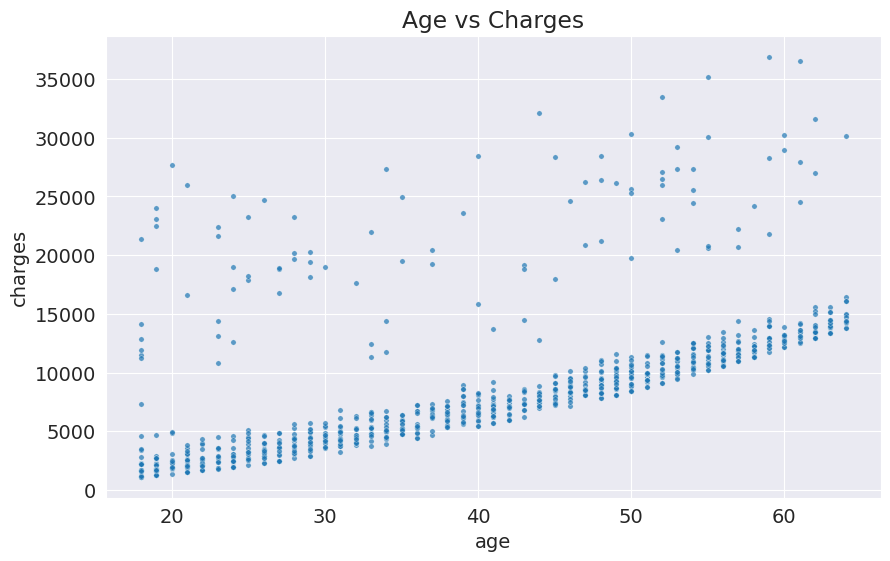

In [13]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
non_smoker_df
plt.title("Age vs Charges")
sns.scatterplot(x = 'age', y = 'charges', data = non_smoker_df, alpha = 0.7, s = 15)

In [14]:
def estimate_charges(age, w, b):
  return w*age+b


estimate_charges(50, 500, -2000)

23000

In [15]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, 298, -2987)
estimated_charges

,age
1,2377
2,5357
3,6847
4,6549
5,6251
...,...
1332,12509
1333,11913
1334,2377
1335,2377


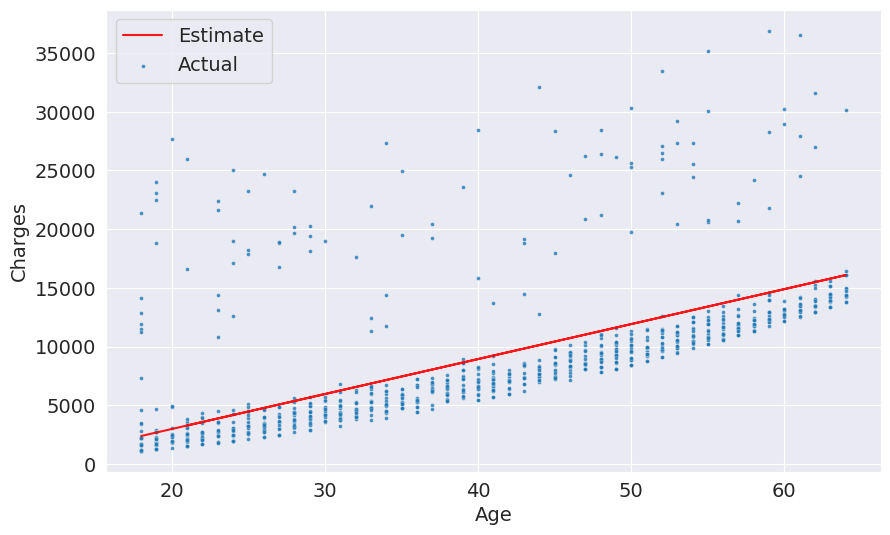

In [16]:
target = non_smoker_df.charges
plt.plot(ages, estimated_charges, color = 'red', alpha = 0.9);
sns.scatterplot(x=ages, y=target, alpha = 0.8, s = 8);
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend(["Estimate", "Actual"])

In [17]:
 targets = non_smoker_df.charges
 predictions = estimated_charges

In [18]:
import numpy as np
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets - predictions)))


RMSE Loss:  8461.949562575493


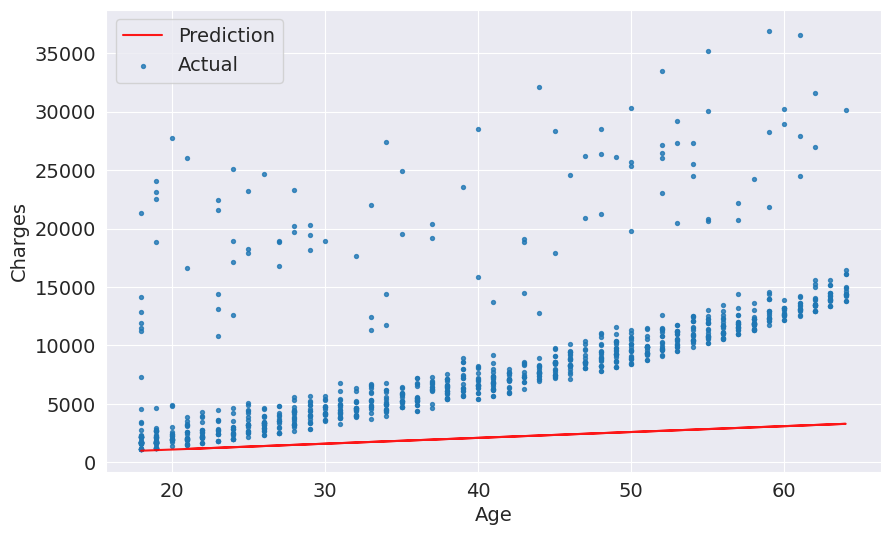

In [19]:
def try_parameters(w, b):
  ages = non_smoker_df.age
  # non_smoker_df.charges is a pandas Series, it cannot be called as a function.
  # We want to use the `estimate_charges` function to get the predictions.
  # The actual charges are `non_smoker_df.charges`.
  predictions = estimate_charges(ages, w, b) # Call the helper function
  actual_charges = non_smoker_df.charges # This is the true target

  plt.plot(ages, predictions, 'r', alpha = 0.9);
  plt.scatter(ages, actual_charges, s = 8, alpha = 0.8); # Use actual_charges here
  plt.xlabel('Age');
  plt.ylabel('Charges')
  plt.legend(['Prediction', 'Actual']);
  loss = rmse(actual_charges, predictions) # Calculate RMSE with actual_charges
  print("RMSE Loss: ", loss)

try_parameters(50, 100)

RMSE Loss:  4685.949631332452


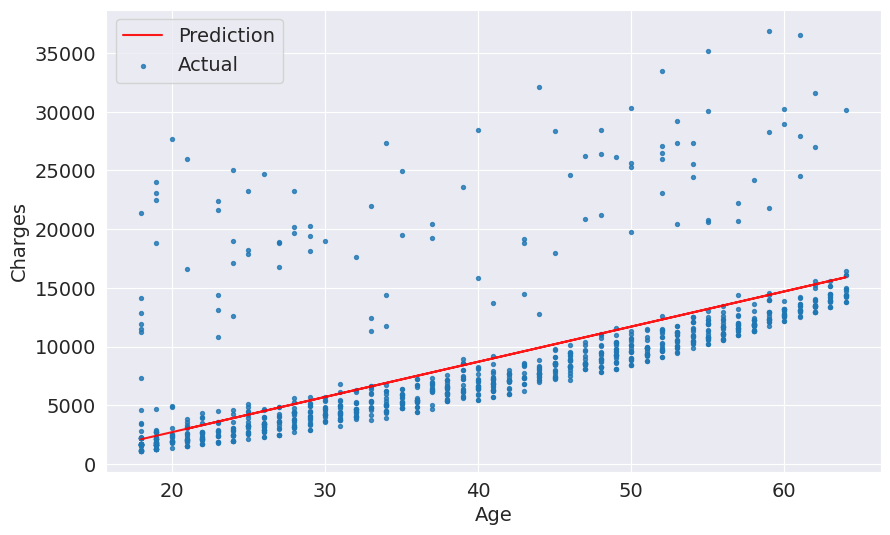

In [20]:
try_parameters(300, -3300)

In [21]:
import sklearn
from sklearn.linear_model import LinearRegression
model = LinearRegression()
help(model.fit)
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape: ', inputs.shape)
print('target.shape:', targets.shape)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.

inputs.shape:  (1064, 1)
target.shape: (1064,)


In [22]:
model.fit(inputs, targets)

LinearRegression()

In [23]:
model.predict(np.array([[23], [37], [61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [24]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [25]:
model.coef_

array([267.24891283])

In [26]:
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss:  4662.505766636395


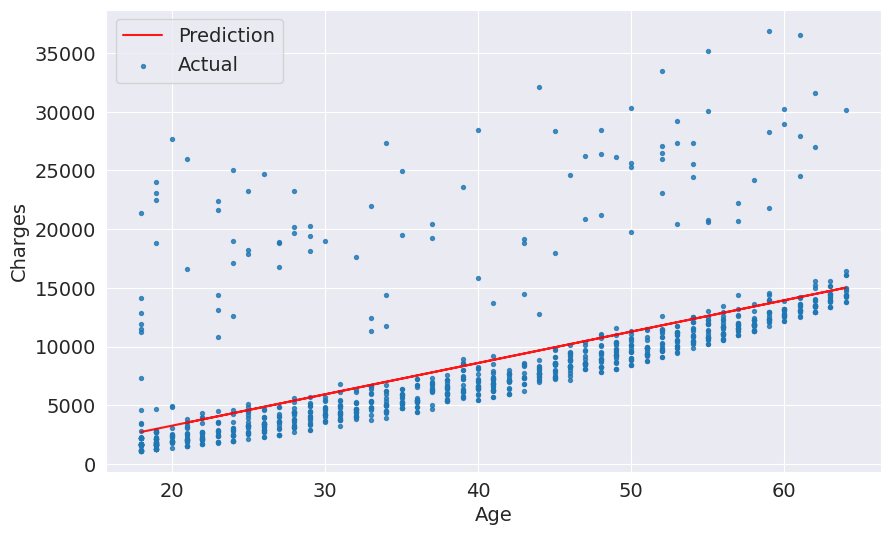

In [27]:
try_parameters(model.coef_, model.intercept_)

In [28]:
from sklearn.linear_model import SGDRegressor
model = SGDRegressor()
model.fit(inputs, targets)

SGDRegressor()

In [29]:
model.predict(np.array([[33], [47], [21]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SGDRegressor was fitted with feature names



array([4478.19066132, 8671.53941138,  883.89173269])

In [30]:
predictions = model.predict(inputs)
predictions

array([ -14.68299946, 2980.56610772, 4478.19066132, ...,  -14.68299946,
        -14.68299946,  883.89173269])

In [31]:
model.coef_

array([299.52491072])

In [32]:
model.intercept_

array([-5406.1313924])

In [33]:
model = SGDRegressor(max_iter = 1000)
help(model.fit)
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
model.fit(inputs, targets)

Help on method fit in module sklearn.linear_model._stochastic_gradient:

fit(X, y, coef_init=None, intercept_init=None, sample_weight=None) method of sklearn.linear_model._stochastic_gradient.SGDRegressor instance
    Fit linear model with Stochastic Gradient Descent.

    Parameters
    ----------
    X : {array-like, sparse matrix}, shape (n_samples, n_features)
        Training data.

    y : ndarray of shape (n_samples,)
        Target values.

    coef_init : ndarray of shape (n_features,), default=None
        The initial coefficients to warm-start the optimization.

    intercept_init : ndarray of shape (1,), default=None
        The initial intercept to warm-start the optimization.

    sample_weight : array-like, shape (n_samples,), default=None
        Weights applied to individual samples (1. for unweighted).

    Returns
    -------
    self : object
        Fitted `SGDRegressor` estimator.



SGDRegressor()

In [34]:
smoker_df = medical_df[medical_df.smoker == 'yes']
model = LinearRegression()
help(model.fit)
inputs = smoker_df[['age']]
targets = smoker_df.charges
print('inputs.shape: ', inputs.shape)
print('target.shape:', targets.shape)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.

inputs.shape:  (274, 1)
target.shape: (274,)


RMSE Loss:  10747.188032948177


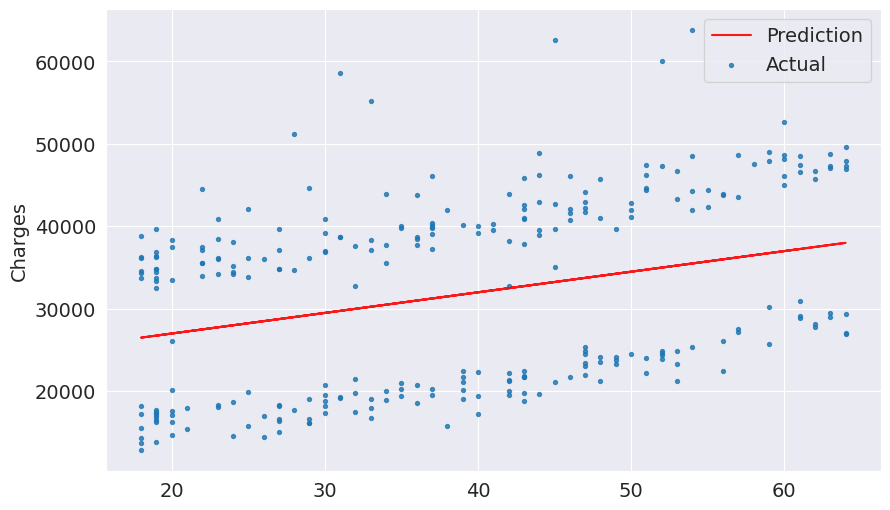

In [35]:
def try_parameters(w, b):
  ages = smoker_df.age

  predictions = estimate_charges(ages, w, b)
  actual_charges = smoker_df.charges
  plt.plot(ages, predictions, 'r', alpha = 0.9);
  plt.scatter(ages, actual_charges, s = 8, alpha = 0.8);
  plt.ylabel('Charges')
  plt.legend(['Prediction', 'Actual']);
  loss = rmse(actual_charges, predictions)
  print("RMSE Loss: ", loss)

try_parameters(250, 21989)

In [36]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [37]:
sex_codes = {'male': 0, 'female': 1}
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [38]:
non_smoker_df = medical_df[medical_df.smoker == 'no'].copy()
inputs, targets = non_smoker_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], non_smoker_df['charges']
model = LinearRegression()
model.fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("RMSE Loss: ", loss)

RMSE Loss:  4601.343101319802


In [39]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [40]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [41]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0.0,0.0,0.0,1.0


In [42]:
non_smoker_df = medical_df[medical_df.smoker == 'no'].copy()
inputs, targets = non_smoker_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']], non_smoker_df['charges']
model = LinearRegression()
model.fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("RMSE Loss: ", loss)

RMSE Loss:  4573.074988795492


In [43]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
medical_df[input_cols].loc[10]

,10
age,25.00
bmi,26.22
children,0.00
smoker_code,0.00
sex_code,0.00
northeast,1.00
northwest,0.00
southeast,0.00
southwest,0.00


In [44]:
model.predict([[19, 16, 0, 0, 0, 0, 1, 0, 0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([2047.67132784])

In [45]:
model.coef_

array([ 2.64481438e+02,  1.89804618e+01,  5.87458257e+02, -2.84217094e-14,
        5.25970487e+02,  7.33683019e+02,  1.85554256e+02, -2.58365372e+02,
       -6.60871903e+02])

In [46]:
model.intercept_

np.float64(-3466.7176413625984)

In [47]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [48]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [49]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [50]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [51]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

In [52]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis = 1)
targets = medical_df.charges
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("RMSE Loss: ", loss)

RMSE Loss:  6041.6796511744515


In [53]:
new_customers = [[28, 30, 2, 1 , 0, 0, 1, 0, 0]]

In [54]:
scaler.transform([[28, 30, 2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [55]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1 , 0, 0, 1, 0, 0.]])

array([29744.50027431])